# [0] 환경 설정 및 데이터 로드

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  데이터 로드 
secom_data = pd.read_csv("Data/secom.data", sep=' ', header=None)
secom_labels = pd.read_csv("Data/secom_labels.data", sep=' ', header=None)

# 컬럼명 지정 및 결합 (Label 컬럼명: Result, Time)
secom_labels.columns = ['Result', 'Time']
secom_df = pd.concat([secom_data, secom_labels['Result']], axis=1)

print(f"데이터 모양: {secom_df.shape}")
secom_df.head()

데이터 모양: (1567, 591)


,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Result
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


# [1] 클래스 불균형 확인

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_70712/3518689673.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Result', data=secom_df, palette='viridis')


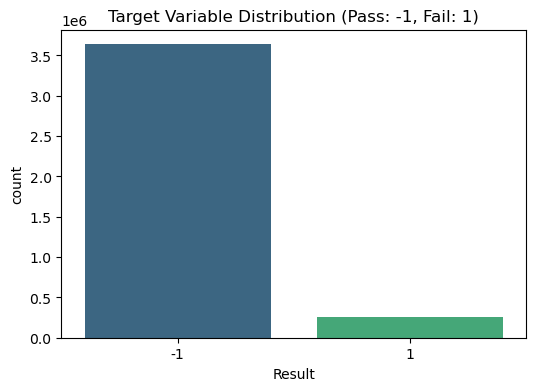

클래스별 샘플 수:
Result
-1    1463
 1     104
Name: count, dtype: int64

불량률: 6.64%


In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Result', data=secom_df, palette='viridis')
plt.title('Target Variable Distribution (Pass: -1, Fail: 1)')
plt.show()

print("클래스별 샘플 수:")
print(secom_df['Result'].value_counts())
print(f"\n불량률: {secom_df['Result'].value_counts()[1] / len(secom_df) * 100:.2f}%")

# [2] 컬럼별 결측치 확인

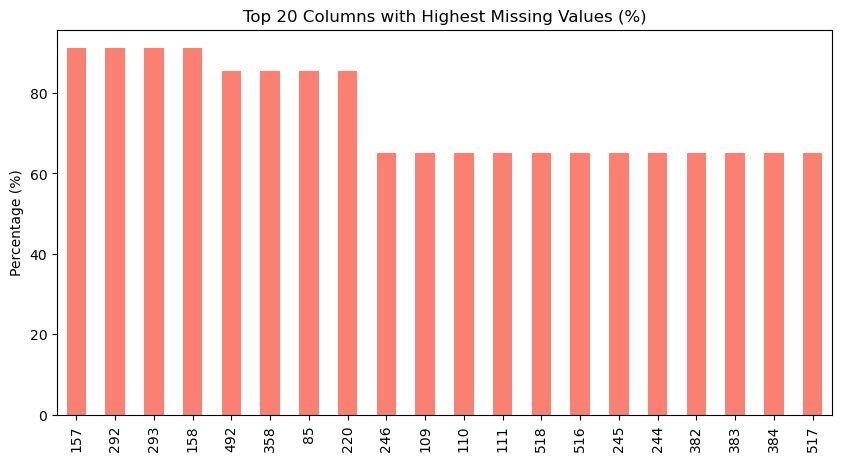

결측치 50% 초과 컬럼 수: 28


In [8]:
# 컬럼별 결측치 비율 계산
nan_counts = secom_df.isnull().sum()
nan_pct = (nan_counts / len(secom_df)) * 100

# 결측치 비율이 높은 상위 20개 컬럼 시각화
plt.figure(figsize=(10, 5))
nan_pct.sort_values(ascending=False)[:20].plot(kind='bar', color='salmon')
plt.title('Top 20 Columns with Highest Missing Values (%)')
plt.ylabel('Percentage (%)')
plt.show()

# 결측치가 50% 이상인 컬럼 확인
trash_cols = nan_pct[nan_pct > 50].index
print(f"결측치 50% 초과 컬럼 수: {len(trash_cols)}")

# [3] Zero Variance Feature 확인

In [9]:
numeric_df = secom_df.drop(columns=['Result'])

# 표준편차가 0인 (모든 값이 같은) 컬럼 찾기
zero_var_cols = numeric_df.columns[numeric_df.std() == 0]

print(f"모든 값이 동일하여 정보 가치가 없는 컬럼 수: {len(zero_var_cols)}")
print(f"해당 컬럼 예시: {list(zero_var_cols[:5])}")

모든 값이 동일하여 정보 가치가 없는 컬럼 수: 116
해당 컬럼 예시: [5, 13, 42, 49, 52]


# [4] 주요 변수 상관관계 확인 

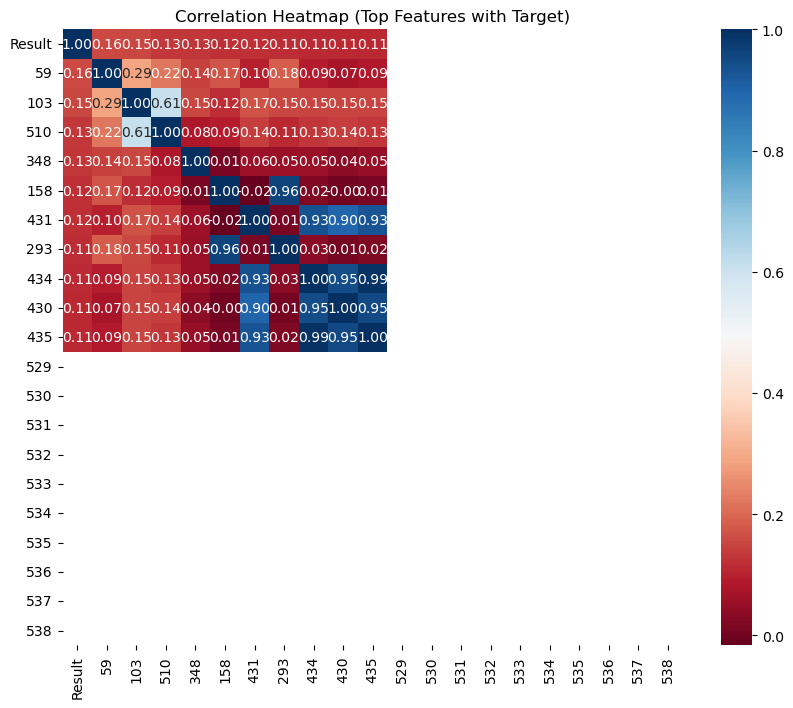

In [10]:
# 상관계수 계산
correlations = secom_df.corr()['Result'].sort_values(ascending=False)

# 타겟과 상관관계가 높은 상위 10개, 하위 10개 변수 결합
top_bottom_features = pd.concat([correlations.head(11), correlations.tail(10)])

plt.figure(figsize=(10, 8))
sns.heatmap(secom_df[top_bottom_features.index].corr(), annot=True, cmap='RdBu', fmt=".2f")
plt.title('Correlation Heatmap (Top Features with Target)')
plt.show()